# Data briefing - Exhibit 3: Historical price shape

**File:** `shape_factors.csv` - `historical_shape_factor`, a robust 2019-2022 Day-Ahead price
shape normalised to annual mean 1. It is a *relative* shape, not a price.

*All reported numbers are rounded to two decimal places.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
DATA = "../../data"

sf = pd.read_csv(f"{DATA}/shape_factors.csv")
sf["is_weekend"] = sf["weekday"] >= 5
s = sf["historical_shape_factor"]

print("rows:", len(sf), "| missing:", int(sf.isna().sum().sum()))
print(f"mean {s.mean():.4f} | std {s.std():.4f} | min {s.min():.4f} | max {s.max():.4f}")
sf.head()

rows: 35136 | missing: 0
mean 1.0000 | std 0.3556 | min 0.1221 | max 2.8376


,timestamp_utc,timestamp_local,month,hour,weekday,is_peak,historical_shape_factor,is_weekend
0,2023-12-31T23:00:00Z,2024-01-01T00:00:00+01:00,1,0,0,0,0.83,False
1,2023-12-31T23:15:00Z,2024-01-01T00:15:00+01:00,1,0,0,0,0.83,False
2,2023-12-31T23:30:00Z,2024-01-01T00:30:00+01:00,1,0,0,0,0.83,False
3,2023-12-31T23:45:00Z,2024-01-01T00:45:00+01:00,1,0,0,0,0.83,False
4,2024-01-01T00:00:00Z,2024-01-01T01:00:00+01:00,1,1,0,0,0.80,False


## 1. What the shape factor is

A dimensionless multiplier around 1. `factor = 1.20` means that hour is priced 20 % **above** the
annual average Day-Ahead level; `0.80` means 20 % **below**. Multiplying a flat block price by the
factor (rescaled to average 1 over the block) redistributes the block value across the hours.

In [2]:
# the factor is a lookup keyed by (month, hour, weekday-type), repeated over the 4 quarter-hours
k1 = sf.groupby(["month", "hour", "weekday"])["historical_shape_factor"].nunique().max()
k2 = sf.groupby(["month", "hour", "is_weekend"])["historical_shape_factor"].nunique().max()
print(f"distinct values within (month,hour,weekday):   {k1}")
print(f"distinct values within (month,hour,is_weekend): {k2}   -> keyed by weekday vs weekend, not by individual day")
print(f"distinct factor values in total: {s.nunique()}  (~ 12 months x 24 hours x 2)")

print("\nmean by peak flag :", sf.groupby("is_peak")["historical_shape_factor"].mean().round(4).to_dict())
q = sf.assign(quarter=((sf.month - 1) // 3 + 1)).groupby("quarter")["historical_shape_factor"].mean()
print("mean by quarter   :", q.round(4).to_dict())

lo, hi = sf.loc[s.idxmin()], sf.loc[s.idxmax()]
wk = {0: "weekday", 1: "weekend"}
print(f"\nlowest  {s.min():.4f}  at month {int(lo.month):>2}, hour {int(lo.hour):>2}, {wk[int(lo.is_weekend)]}")
print(f"highest {s.max():.4f}  at month {int(hi.month):>2}, hour {int(hi.hour):>2}, {wk[int(hi.is_weekend)]}")

distinct values within (month,hour,weekday):   1
distinct values within (month,hour,is_weekend): 1   -> keyed by weekday vs weekend, not by individual day
distinct factor values in total: 552  (~ 12 months x 24 hours x 2)

mean by peak flag : {0: 0.9071, 1: 1.1666}
mean by quarter   : {1: 0.8943, 2: 0.8873, 3: 1.1234, 4: 1.0926}

lowest  0.1221  at month  5, hour 14, weekend
highest 2.8376  at month  9, hour 19, weekday


## 2. Month-hour heatmap

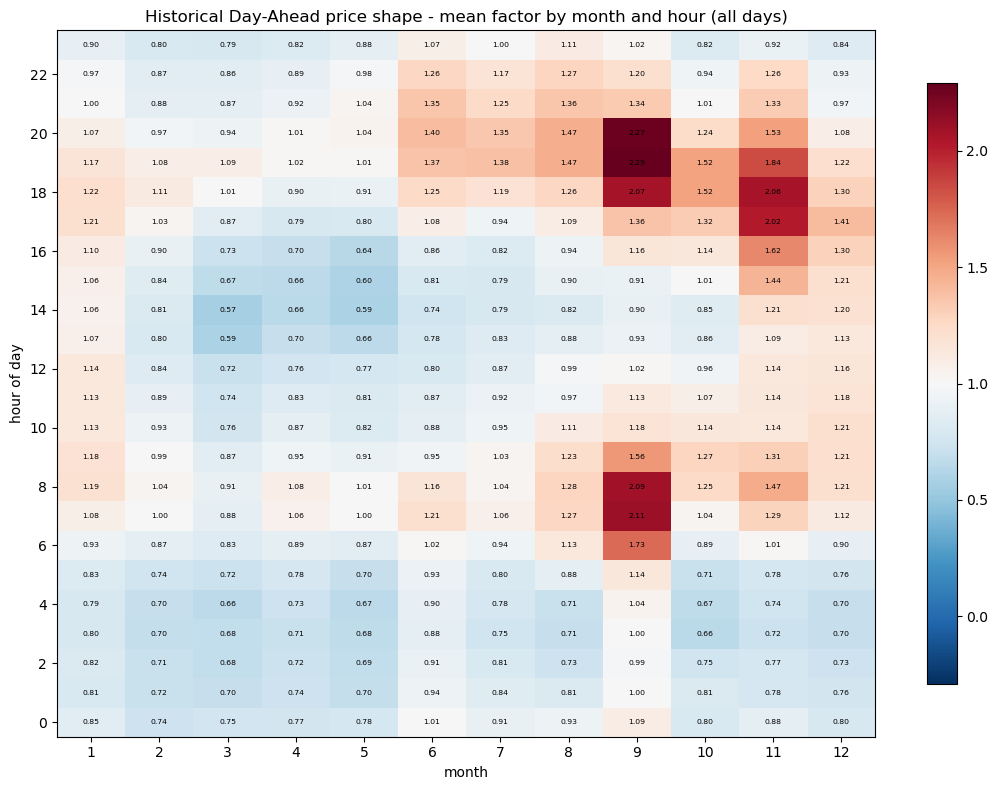

In [3]:
alld = sf.pivot_table("historical_shape_factor", "hour", "month", aggfunc="mean")

def heatmap(ax, M, title, center, cmap):
    span = np.nanmax(np.abs(M.values - center))
    norm = TwoSlopeNorm(vcenter=center, vmin=center - span, vmax=center + span)
    im = ax.imshow(M.values, aspect="auto", origin="lower", cmap=cmap, norm=norm)
    ax.set_xticks(range(12)); ax.set_xticklabels(range(1, 13))
    ax.set_yticks(range(0, 24, 2)); ax.set_yticklabels(range(0, 24, 2))
    ax.set_xlabel("month"); ax.set_ylabel("hour of day"); ax.set_title(title)
    for (i, j), v in np.ndenumerate(M.values):
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=5.5)
    plt.colorbar(im, ax=ax, shrink=0.85)

fig, ax = plt.subplots(figsize=(11, 8))
heatmap(ax, alld, "Historical Day-Ahead price shape - mean factor by month and hour (all days)",
        1.0, "RdBu_r")
plt.tight_layout(); plt.show()

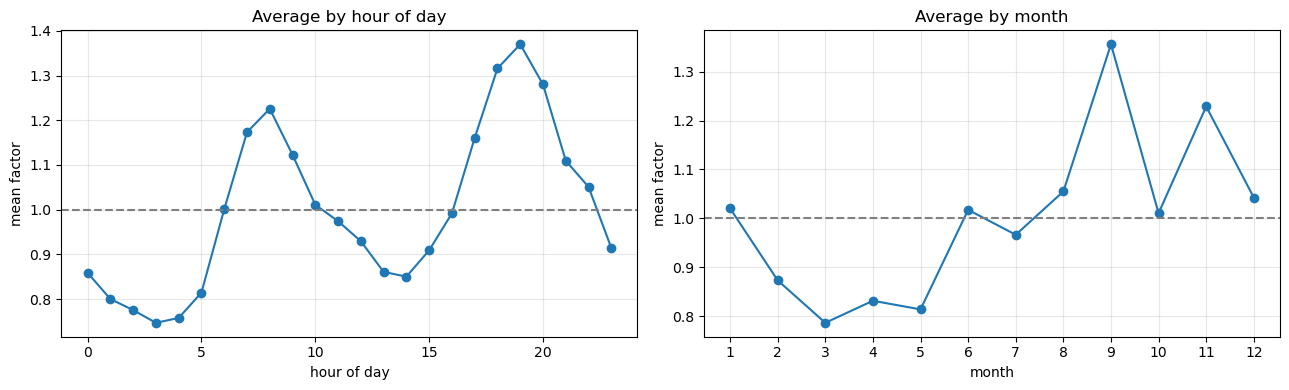

highest hours : {19: 1.37, 18: 1.32, 20: 1.28}
lowest hours  : {3: 0.75, 4: 0.76, 2: 0.78}
highest months: {9: 1.36, 11: 1.23, 8: 1.06}
lowest months : {3: 0.79, 5: 0.81, 4: 0.83}
share of quarter-hours with factor > 1: 41.62%


In [4]:
by_hour  = sf.groupby("hour")["historical_shape_factor"].mean()
by_month = sf.groupby("month")["historical_shape_factor"].mean()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
by_hour.plot(marker="o", ax=a1);  a1.axhline(1, color="grey", ls="--")
a1.set_xlabel("hour of day"); a1.set_ylabel("mean factor"); a1.set_title("Average by hour of day"); a1.grid(alpha=.3)
by_month.plot(marker="o", ax=a2); a2.axhline(1, color="grey", ls="--")
a2.set_xlabel("month"); a2.set_ylabel("mean factor"); a2.set_title("Average by month"); a2.set_xticks(range(1,13)); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("highest hours :", by_hour.nlargest(3).round(2).to_dict())
print("lowest hours  :", by_hour.nsmallest(3).round(2).to_dict())
print("highest months:", by_month.nlargest(3).round(2).to_dict())
print("lowest months :", by_month.nsmallest(3).round(2).to_dict())
print(f"share of quarter-hours with factor > 1: {100*(s > 1).mean():.2f}%")

### Reading the heatmap

- **Above / below 1.** Blue cells (> 1) are hours historically priced above the yearly average,
  red cells (< 1) below it. Only **41.62 %** of quarter-hours sit above 1 - the average is held at
  1 by a minority of very expensive evening hours (std of the factor is 0.36).
- **Daily pattern.** A morning shoulder around **07-08 h**, a pronounced **evening peak at
  18-20 h** (hourly means 1.32 / 1.37 / 1.28), a **midday dip** (hours 11-15) and a deep
  **overnight trough** at **02-04 h** (means 0.78 / 0.75 / 0.76).
- **Seasonal pattern.** Highest months are **September (1.36), November (1.23), August (1.06)**;
  lowest are **March (0.79), May (0.81), April (0.83)**. By quarter: Q1 0.89, Q2 0.89, Q3 1.12,
  Q4 1.09. In spring the midday hours fall well below 1 (all-day mean ~0.57 at 13-14 h); in winter
  the same hours stay above 1.
- **Extremes.** Minimum **0.12** (May, 14 h, weekend), maximum **2.84** (September, 19 h, weekday).

## 3. The shape and the Peak definition

Peak = Monday-Friday 08:00-20:00. The shape shows how well that fixed window captures the
genuinely expensive hours.

In [5]:
pk = (sf.groupby(["month", "is_peak"])["historical_shape_factor"].mean().unstack()
        .rename(columns={0: "off_peak", 1: "peak"}))
pk["peak - off_peak"] = pk["peak"] - pk["off_peak"]
print("Mean factor by month, Peak vs Off-Peak")
print(pk.round(2))

print(f"\noverall: peak {sf.loc[sf.is_peak==1,'historical_shape_factor'].mean():.2f}"
      f"  off-peak {sf.loc[sf.is_peak==0,'historical_shape_factor'].mean():.2f}")
print(f"peak quarter-hours with factor <= 1 : {100*(sf.loc[sf.is_peak==1,'historical_shape_factor'] <= 1).mean():.2f}%")
print(f"off-peak quarter-hours with factor > 1: {100*(sf.loc[sf.is_peak==0,'historical_shape_factor'] > 1).mean():.2f}%")

# which hours are 'expensive' (factor > 1 on average) but sit OUTSIDE the peak window?
hour_mean = sf.groupby(["hour"])["historical_shape_factor"].mean()
outside = [h for h in range(24) if hour_mean[h] > 1 and not (8 <= h < 20)]
print("hours with mean factor > 1 that are OUTSIDE 08-20:", outside)

Mean factor by month, Peak vs Off-Peak
is_peak  off_peak  peak  peak - off_peak
month                                   
1            0.94  1.16             0.23
2            0.80  1.00             0.20
3            0.72  0.92             0.19
4            0.80  0.89             0.09
5            0.77  0.89             0.13
6            0.95  1.16             0.21
7            0.93  1.03             0.10
8            0.95  1.25             0.30
9            1.20  1.65             0.45
10           0.95  1.11             0.15
11           0.98  1.69             0.70
12           0.89  1.31             0.42

overall: peak 1.17  off-peak 0.91
peak quarter-hours with factor <= 1 : 33.46%
off-peak quarter-hours with factor > 1: 27.73%
hours with mean factor > 1 that are OUTSIDE 08-20: [6, 7, 20, 21, 22]


**What this shows.** Peak hours average **1.17** against **0.91** off-peak, so the 08-20 window does
sit on the higher-priced part of the day. But the match is loose:

- **33.46 %** of peak quarter-hours are actually **at or below** the yearly average. In spring the
  monthly *peak* mean is only ~0.89 (Apr, May) - the 11-15 h solar hours fall inside the window yet
  price below 1.
- **27.73 %** of off-peak quarter-hours are **above** 1: the evening ramp spills past 20:00, so
  hours **06, 07, 20, 21, 22** carry a mean factor above 1 while being classified Off-Peak.
- The Peak-minus-Off-Peak gap is highly seasonal: largest in autumn (**Nov +0.70, Sep +0.45,
  Dec +0.42**), smallest in spring/summer (**Apr +0.09, Jul +0.10**).

A single Base/Peak split therefore leaves real intra-window and seasonal structure that only an
hourly shape can express.

## 4. Weekday vs weekend

max |weekday - weekend| over (month,hour): 1.83


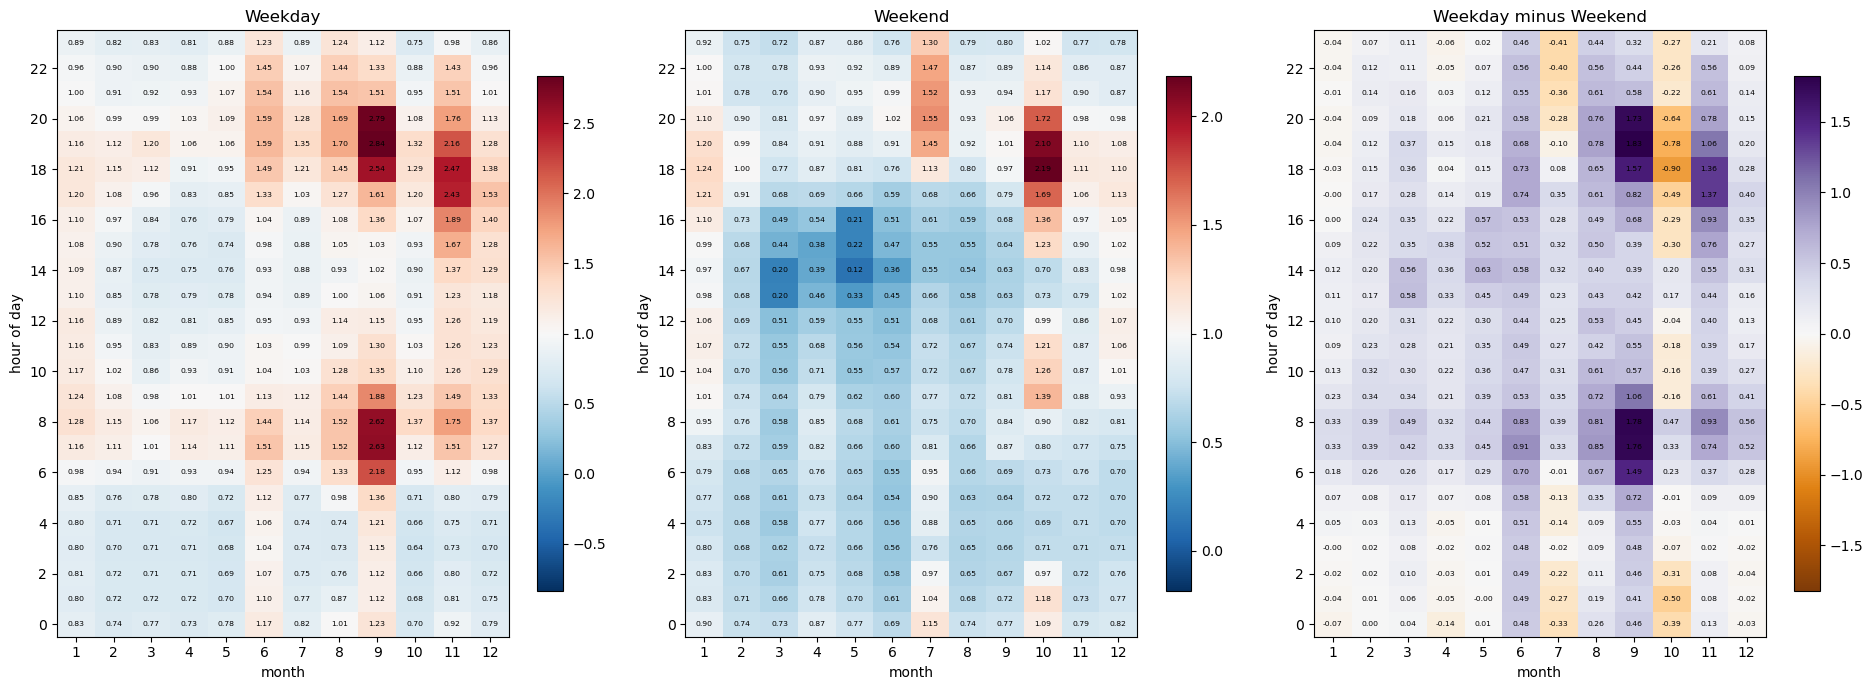


mean by weekday (Mon=0): {0: 1.09, 1: 1.08, 2: 1.07, 3: 1.08, 4: 1.08, 5: 0.8, 6: 0.8}
08-20 window: weekday 1.17  vs weekend 0.79


In [6]:
wd = sf[~sf.is_weekend].pivot_table("historical_shape_factor", "hour", "month", aggfunc="mean")
we = sf[ sf.is_weekend].pivot_table("historical_shape_factor", "hour", "month", aggfunc="mean")
diff = wd - we
print(f"max |weekday - weekend| over (month,hour): {np.abs(diff.values).max():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(19, 7))
heatmap(axes[0], wd,   "Weekday",              1.0, "RdBu_r")
heatmap(axes[1], we,   "Weekend",              1.0, "RdBu_r")
heatmap(axes[2], diff, "Weekday minus Weekend", 0.0, "PuOr")
plt.tight_layout(); plt.show()

byday = sf.groupby("weekday")["historical_shape_factor"].mean()
print("\nmean by weekday (Mon=0):", byday.round(2).to_dict())
bh = sf[(sf.hour >= 8) & (sf.hour < 20)]
print(f"08-20 window: weekday {bh.loc[~bh.is_weekend,'historical_shape_factor'].mean():.2f}"
      f"  vs weekend {bh.loc[bh.is_weekend,'historical_shape_factor'].mean():.2f}")

**What this shows.** Weekends are lower and flatter. The mean factor is ~1.08 on Mon-Fri but
**0.80** on Sat and Sun. Overnight hours are almost identical, but across the 08-20 window the
weekday mean is **1.17** against **0.79** on weekends - the working-day demand block is missing.
The largest single month-hour gap between the two profiles is **1.83**. This is why the shape is
stored per weekday-type: one all-day profile would overprice weekend daytime hours and underprice
weekday daytime hours.

## 5. From block futures to an hourly curve

A relative shape turns a flat block quote into an hourly curve without changing the quote's
average. Within a calibration block and slice (Peak or Off-Peak):

$$\text{HPFC}_t = P_\text{slice} \cdot \frac{s_t}{\overline{s}_\text{slice}}$$

Dividing by the slice mean guarantees the hourly curve still averages to the traded price.
Worked example with the Q4 2024 futures.

Q4: Base 101.39, Peak 134.42  ->  implied Off-Peak 82.93   (N_all 8836, N_peak 3168, N_off 5668)
mean HPFC over Q4 (all)  : 101.39   should equal Base 101.39
mean HPFC over Q4 peak   : 134.42   should equal Peak 134.42
HPFC range in Q4         : 56.26 to 244.48 EUR/MWh


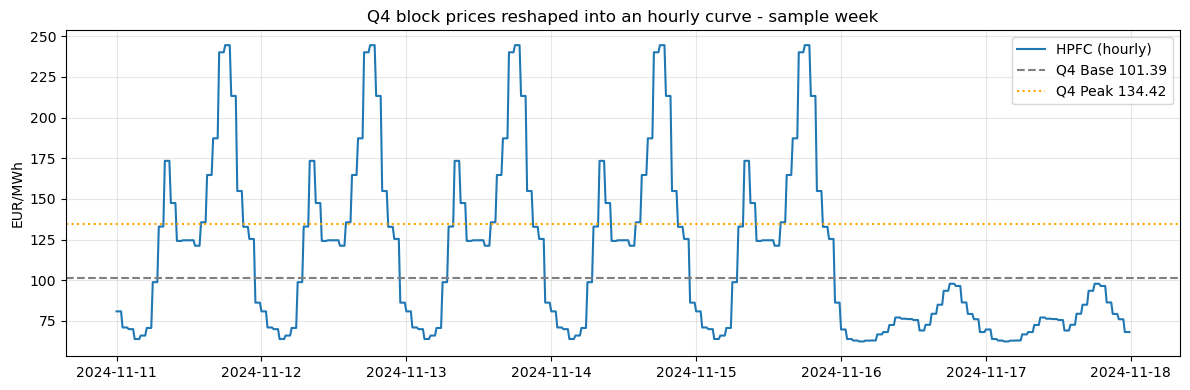

In [7]:
fut = pd.read_csv(f"{DATA}/futures_prices.csv")
def price(period, lt):
    return fut.loc[(fut.delivery_period == period) & (fut.load_type == lt), "price_eur_mwh"].iloc[0]

q4 = sf[sf.month.isin([10, 11, 12])].copy()
Pb, Pp = price("Q4", "BASE"), price("Q4", "PEAK")
N_all = len(q4); N_pk = int((q4.is_peak == 1).sum()); N_off = N_all - N_pk
P_off = (Pb * N_all - Pp * N_pk) / N_off
print(f"Q4: Base {Pb:.2f}, Peak {Pp:.2f}  ->  implied Off-Peak {P_off:.2f}   "
      f"(N_all {N_all}, N_peak {N_pk}, N_off {N_off})")

mean_pk  = q4.loc[q4.is_peak == 1, "historical_shape_factor"].mean()
mean_off = q4.loc[q4.is_peak == 0, "historical_shape_factor"].mean()
q4["hpfc"] = np.where(q4.is_peak == 1,
                      Pp    * q4.historical_shape_factor / mean_pk,
                      P_off * q4.historical_shape_factor / mean_off)

print(f"mean HPFC over Q4 (all)  : {q4.hpfc.mean():.2f}   should equal Base {Pb:.2f}")
print(f"mean HPFC over Q4 peak   : {q4.loc[q4.is_peak==1,'hpfc'].mean():.2f}   should equal Peak {Pp:.2f}")
print(f"HPFC range in Q4         : {q4.hpfc.min():.2f} to {q4.hpfc.max():.2f} EUR/MWh")

q4["t"] = pd.to_datetime(q4["timestamp_utc"], utc=True).dt.tz_convert("Europe/Berlin").dt.tz_localize(None)
wkm = q4[(q4.t >= "2024-11-11") & (q4.t < "2024-11-18")]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wkm.t, wkm.hpfc, label="HPFC (hourly)")
ax.axhline(Pb, color="grey",   ls="--", label=f"Q4 Base {Pb:.2f}")
ax.axhline(Pp, color="orange", ls=":",  label=f"Q4 Peak {Pp:.2f}")
ax.set_ylabel("EUR/MWh"); ax.set_title("Q4 block prices reshaped into an hourly curve - sample week")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

**What this shows.** The single Q4 Base quote (**101.39** EUR/MWh) becomes an hourly curve ranging
from **56.26** to **244.48** EUR/MWh, with evening hours well above and night hours well below the
block price. Averaged back over all Q4 hours the curve returns **101.39** exactly, and over the
Peak hours it returns the Peak quote **134.42** - the shape redistributes value, it does not add or
remove it. (Implied Q4 Off-Peak price: 82.93 EUR/MWh.)

## Conclusion - what the historical shape adds to the futures quotes

The futures market only prices **broad averages**: one number for the whole year, the quarter or
the month, split at best into Base and Peak. The historical shape supplies the **within-block
structure** those quotes cannot carry:

- the **daily profile** - morning ramp, midday dip, evening peak, overnight trough;
- how that profile **changes with the season** (flat-ish winter midday vs. deep spring solar dip);
- the **weekday/weekend** difference in the daytime hours;
- a contract-consistent way to **rescale** a block price into an hourly curve (divide by the slice
  mean) so the hourly curve still reprices every traded block.

It is a *shape*, not a forecast: it says how hours have historically related to each other, not
what 2024 Day-Ahead prices will be. Combined with the traded price *levels* from Exhibit 2 it is
the basis for the HPFC in Stage 2.